# 12 · Lazy Execution, Persistence, and Resource Ownership

**Topics:** Chunked payloads; metadata inspection; planning versus execution; compute and persist; Zarr semantics; CSV interchange; graph context; cleanup and current lazy boundaries.

**After this notebook:** plan a lazy analysis and keep its backing resources available through computation.

**Prerequisites:** Notebooks 02, 06, and 08. Run this notebook independently, top to bottom;
see [setup and navigation](README.md). Every variation is worked through below.
The small examples expose the semantics before the recorded-log application.

In [1]:
from examples.tutorial.presentation import BLUE, GRAY, configure, show

configure()

import warnings
from pathlib import Path
from tempfile import TemporaryDirectory

import numpy as np
import pandas as pd
import xarray as xr
from dask.callbacks import Callback
from IPython.display import display

from tal import AnalysisObject
from tal.io import AOZarrReadOptions, CsvIngestOptions, read_csv_logs, write_csv_logs
from tal.spatial import Position

In [2]:
import matplotlib.pyplot as plt

from tal.core import AnalysisLayoutSpec
from tal.frames import FrameGraph

## Work from metadata before reading payload values

Use a small in-memory chunked AO to see planning independently of file I/O. Direct
display and chunk inspection do not require computing numerical values. Constructing
the reduction builds a lazy graph. The schematic uses chunk sizes, not an eager
payload conversion. Dask support belongs to each operation; it should not be assumed
merely because the input contains chunks.

<tal.AnalysisObject> Size: 96B
Dimensions:  (sample: 12)
TAL:
    Sequence: sample
    Batch: ()
    Core: ()
Dimensions without coordinates: sample
Data variables:
    signal   (sample) float64 96B dask.array<chunksize=(4,), meta=np.ndarray>

<tal.AnalysisObject> Size: 8B
Dimensions:  ()
TAL:
    Sequence: none
    Batch: ()
    Core: ()
Data variables:
    signal   float64 8B dask.array<chunksize=(), meta=np.ndarray>

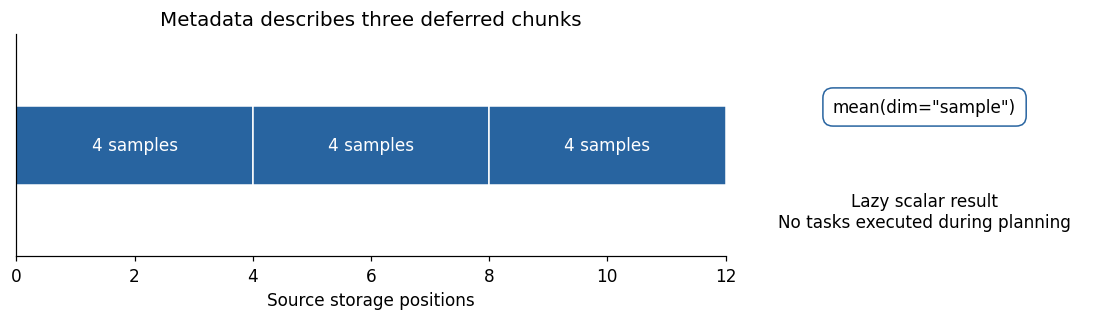

In [3]:
memory_source = AnalysisLayoutSpec(sequence_dim="sample").wrap(
    xr.DataArray(np.arange(12, dtype=float), dims="sample", name="signal").chunk(
        {"sample": 4}
    )
)
memory_tasks = []
with Callback(posttask=lambda key, *args: memory_tasks.append(key)):
    memory_plan = memory_source.mean(dim="sample")
assert memory_tasks == []
display(memory_source)
display(memory_plan)
fig, axes = plt.subplots(
    1, 2, figsize=(10, 2.8), layout="constrained", gridspec_kw={"width_ratios": [2, 1]}
)
for start in [0, 4, 8]:
    axes[0].barh(0, 4, left=start, height=0.5, edgecolor="white", color=BLUE)
    axes[0].text(start + 2, 0, "4 samples", color="white", ha="center", va="center")
axes[0].set(
    xlim=(0, 12),
    ylim=(-0.7, 0.7),
    yticks=[],
    xlabel="Source storage positions",
    title="Metadata describes three deferred chunks",
)
axes[1].axis("off")
axes[1].text(
    0.5,
    0.65,
    'mean(dim="sample")',
    ha="center",
    bbox={"boxstyle": "round,pad=.6", "facecolor": "white", "edgecolor": BLUE},
)
axes[1].text(
    0.5,
    0.2,
    "Lazy scalar result\nNo tasks executed during planning",
    ha="center",
    va="center",
)
show(fig)

## Worked comparison: compute, memory persist, and storage persistence

`compute()` returns realized xarray data. `persist()` executes and retains Dask-backed
results in memory under the scheduler; it is not a durable file. `ao.io.to_zarr()`
writes a complete persistent AO snapshot. Use explicit xarray exposure for compute
and persist because these are xarray/Dask APIs, not invented AO methods. The small
summary is the useful computation boundary here.

In [4]:
execution_tasks = []
with Callback(posttask=lambda key, *args: execution_tasks.append(key)):
    computed_memory = memory_plan.as_dataset(copy="shallow").compute()
assert execution_tasks
persisted_memory = memory_source.as_dataset(copy="shallow").persist()
display(
    pd.DataFrame(
        {
            "operation": ["plan mean", "compute summary", "persist source payload"],
            "numerical work": ["deferred", "executed", "executed"],
            "Dask backing retained": [
                memory_plan.to_dataarray(copy="shallow").chunks is not None,
                computed_memory.signal.chunks is not None,
                persisted_memory.signal.chunks is not None,
            ],
        }
    )
)
np.testing.assert_allclose(computed_memory.signal, 5.5)

,operation,numerical work,Dask backing retained
0,plan mean,deferred,True
1,compute summary,executed,False
2,persist source payload,executed,True


The callback observed execution only when `compute()` was called. The result is the
ordinary xarray scalar 5.5. `persist()` also executes, but retains a Dask-backed object
whose chunks are held by the scheduler. Neither operation writes a durable snapshot.
The Zarr example below introduces storage and therefore a separate resource lifetime.

## A canonical round trip and an explicit computation boundary
Zarr preserves decoded values and TAL schema. Reopening validates small validity
metadata eagerly; data variables remain lazy. The callback below starts **after**
opening so it measures planning, not metadata reads. `compute()` is the deliberate
payload boundary. Close the derived wrapper and source before removing storage.

The installed Zarr 3 writer emits a notice about consolidated-metadata portability. It does not invalidate the decoded round-trip check below.

Assemble a `Position` directly from the reopened fields, take its norm, and
average over each trial's recorded samples. This measures distance from the world
origin, not distance traveled or distance to the deck. Different recording lengths
also mean these averages are not a fair controller ranking. Field assembly and
these reductions build a lazy graph; `compute()` is the deliberate execution boundary.

In [5]:
data_dir = Path("data/flight_telemetry")
if not data_dir.is_dir():
    data_dir = Path("examples/tutorial/data/flight_telemetry")
observations = read_csv_logs(
    str(data_dir / "observations/*.csv"), opts=CsvIngestOptions(time_col="time")
)

In [6]:
with TemporaryDirectory(prefix="tal-tutorial-") as temporary:
    output_dir = Path(temporary)
    with warnings.catch_warnings(record=True) as storage_notices:
        observations.io.to_zarr(str(output_dir / "flight.zarr"))
    for notice in storage_notices:
        print(f"{notice.category.__name__}: {notice.message}")
    lazy = AnalysisObject.from_zarr(
        str(output_dir / "flight.zarr"), opts=AOZarrReadOptions(chunks={})
    )
    try:
        assert lazy.as_dataset(copy="shallow")["altitude"].chunks is not None
        planning_tasks = []
        with Callback(posttask=lambda key, *args: planning_tasks.append(key)):
            lazy_position = Position.from_fields(
                lazy, "drone.position.{x,y,z}", parent="world", child="drone"
            )
            planned = lazy_position.norm().mean(dim="sample")
        assert planning_tasks == []
        display(planned)
        try:
            result = planned.as_dataset(copy="shallow").compute()
            decoded = lazy.as_dataset(copy="shallow").compute()
        finally:
            planned.close()
            lazy_position.close()
        xr.testing.assert_identical(decoded, observations.as_dataset(copy="shallow"))
    finally:
        lazy.close()
    csv_paths = write_csv_logs(
        observations.select_vars("altitude"), str(output_dir / "csv")
    )
    exported = pd.read_csv(csv_paths[0])
    assert "tal" not in exported.columns
assert not output_dir.exists()
xyz = observations.as_dataset(copy="shallow")[
    [f"drone.position.{axis}" for axis in "xyz"]
].to_array("axis")
expected = np.sqrt((xyz**2).sum("axis", skipna=False)).mean("sample")
np.testing.assert_allclose(result["datavar"], expected)
result

<tal.AnalysisObject> Size: 192B
Dimensions:  (trial: 12)
TAL:
    Sequence: none
    Batch: (trial)
    Core: ()
Coordinates:
             Role
  * trial    batch  (trial) object 96B 'flight_01' 'flight_02' ... 'flight_12'
Data variables:
    datavar  (trial) float64 96B dask.array<chunksize=(12,), meta=np.ndarray>

<xarray.Dataset> Size: 192B
Dimensions:  (trial: 12)
Coordinates:
  * trial    (trial) object 96B 'flight_01' 'flight_02' ... 'flight_12'
Data variables:
    datavar  (trial) float64 96B 5.922 6.784 6.349 7.26 ... 7.315 7.45 7.472
Attributes:
    tal:      {'version': 1, 'core': {'roles': {'batch_dims': ['trial'], 'cor...

## Trace the resource lifetime alongside the result

Read the `try/finally` blocks above from the outside inward. The temporary directory
owns the store; the reopened wrapper owns access to its backend; derived expressions
must finish their reads before those resources are closed and removed.

The small `result` has already been computed, so it remains usable after cleanup.
`decoded` verifies the complete decoded Dataset and schema before the store disappears.
The diagram follows those actual code boundaries, without treating a deferred graph
as a self-contained copy of its backing storage.

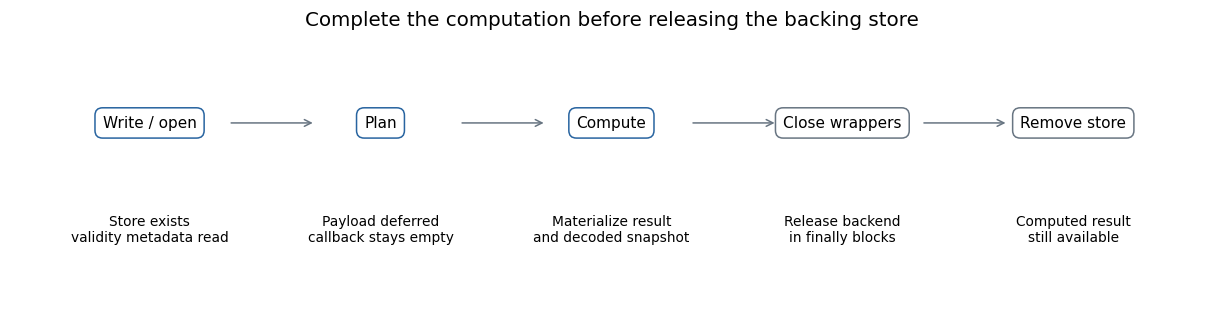

<xarray.Dataset> Size: 192B
Dimensions:  (trial: 12)
Coordinates:
  * trial    (trial) object 96B 'flight_01' 'flight_02' ... 'flight_12'
Data variables:
    datavar  (trial) float64 96B 5.922 6.784 6.349 7.26 ... 7.315 7.45 7.472
Attributes:
    tal:      {'version': 1, 'core': {'roles': {'batch_dims': ['trial'], 'cor...

In [7]:
stages = ["Write / open", "Plan", "Compute", "Close wrappers", "Remove store"]
notes = [
    "Store exists\nvalidity metadata read",
    "Payload deferred\ncallback stays empty",
    "Materialize result\nand decoded snapshot",
    "Release backend\nin finally blocks",
    "Computed result\nstill available",
]
fig, ax = plt.subplots(figsize=(11, 2.8), layout="constrained")
ax.axis("off")
for i, (stage, note) in enumerate(zip(stages, notes, strict=True)):
    ax.text(
        i,
        0.65,
        stage,
        ha="center",
        va="center",
        fontsize=10,
        bbox={
            "boxstyle": "round,pad=.5",
            "facecolor": "white",
            "edgecolor": BLUE if i < 3 else GRAY,
        },
    )
    ax.text(i, 0.05, note, ha="center", va="center", fontsize=9)
    if i < 4:
        ax.annotate(
            "",
            (i + 0.72, 0.65),
            (i + 0.34, 0.65),
            arrowprops={"arrowstyle": "->", "color": GRAY},
        )
ax.set(
    xlim=(-0.6, 4.6),
    ylim=(-0.4, 1.15),
    title="Complete the computation before releasing the backing store",
)
show(fig)
display(result[["datavar"]])

## Persisted declarations and runtime graphs have different lifetimes

Frame IDs are semantic metadata. A remembered graph is wrapper-local runtime context
and is not stored in the Dataset. Reattach graph context explicitly for later path
operations; association alone does not register a provider. The detached conversion
below keeps the declared relation while showing that the graph association is absent.

Dataset conversion retains the serializable world → drone relation. A graph contains
runtime nodes and providers, so the converted Position has no remembered association.
`with_graph` restores that association for later lookup; provider registration remains
a separate action. A file snapshot therefore needs an explicit runtime context for paths.

In [8]:
runtime_graph = FrameGraph()
associated_position = Position.from_fields(
    observations,
    "drone.position.{x,y,z}",
    parent="world",
    child="drone",
    graph=runtime_graph,
)
dataset_position = Position(associated_position.as_dataset())
assert dataset_position.frames.ids() == ("world", "drone")
assert dataset_position.graph is None
reattached_position = dataset_position.with_graph(runtime_graph)
assert reattached_position.graph is runtime_graph
display(
    pd.DataFrame(
        {
            "view": ["associated", "Dataset conversion", "reattached"],
            "relation": [
                v.frames.ids()
                for v in (associated_position, dataset_position, reattached_position)
            ],
            "remembered graph": [
                v.graph is not None
                for v in (associated_position, dataset_position, reattached_position)
            ],
        }
    )
)

,view,relation,remembered graph
0,associated,"(world, drone)",True
1,Dataset conversion,"(world, drone)",False
2,reattached,"(world, drone)",True


## What each format promises
The decoded Zarr round trip preserves schema and ragged lengths; storage encodings
and chunk layout are implementation choices. CSV is a lossy table export: numerical
columns and timestamps are useful outside TAL, but it does not preserve the complete
schema, component registry, or resources. A later CSV read needs its own declarations.

Keep lazy work inside the resource lifetime. Do not expect a lazy expression to work
after its backing storage is removed. Displays show lazy metadata, whereas plotting
and explicit computation may read payloads.

Condition-driven event discovery has additional restrictions: chunked boundary queries
need bounded capacity where documented, and `around` on a lazy source requires explicit
anchors rather than an unbounded condition scan. This notebook demonstrates selection
and reduction without adding custom discovery logic. Continue to [visualization](13_visualization_holoviews_explorer.ipynb).

The worked examples separate storage format guarantees from execution guarantees. Zarr preserves decoded TAL semantics within xarray serialization; exact chunk layouts, encodings, and runtime graph objects are not persistent identity. Linear-system operations currently require eager inputs; condition-driven lazy events require their documented bounded or explicit-anchor support.